# Term Project 3: Multi-Country State Estimation with Particle Filters

The project brief defines a **single-country, single-latent-state** state-space model. The proper multi-country extension is therefore:

- keep the **same model structure** for each country,
- estimate the model **separately country by country**, and
- compare the resulting parameter estimates and latent output-gap paths across countries.

A pooled panel model or a hierarchical cross-country state-space model would be possible, but that would go beyond the PDF guidance.

## Notebook Structure

1. **Synthetic experiment** to validate the MLE / Kalman filter / particle filter workflow.
2. **Multi-country empirical application** for eight countries with complete 1961-2024 coverage in `GDP_DATA.csv`.

## Identification Choice

The latent-state scale is not separately identified from `beta` and the state variance if all are estimated freely from a single observed series. As in the single-country notebook, I therefore:

- fix the state innovation variance at `q = 1`,
- estimate `alpha`, `beta`, and `r`, and
- demean each country's GDP growth so the latent state can be interpreted as a zero-mean cyclical output-gap proxy.

A small floor `r >= 0.05` is imposed to prevent a degenerate zero-noise solution.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

np.set_printoptions(precision=4, suppress=True)
pd.options.display.float_format = "{:,.4f}".format

PROJECT_Q = 1.0
R_FLOOR = 0.05
RNG_SEED = 4703
COUNTRIES = [
    "United States",
    "Canada",
    "Germany",
    "France",
    "United Kingdom",
    "Japan",
    "China",
    "India",
]

print("Notebook initialized.")
print(f"Countries: {', '.join(COUNTRIES)}")
print(f"Fixed process variance q = {PROJECT_Q:.1f}")
print(f"Measurement variance constrained to r >= {R_FLOOR:.2f}")


Notebook initialized.
Countries: United States, Canada, Germany, France, United Kingdom, Japan, China, India
Fixed process variance q = 1.0
Measurement variance constrained to r >= 0.05


## Load the GDP Data

The selected country basket has full annual coverage from 1961 to 2024, which keeps the cross-country comparison clean.


In [2]:
gdp_df = pd.read_csv("GDP_DATA.csv")

country_overview = []
for country in COUNTRIES:
    series = gdp_df[["YEAR", country]].dropna()
    country_overview.append(
        {
            "country": country,
            "observations": len(series),
            "start_year": int(series["YEAR"].min()),
            "end_year": int(series["YEAR"].max()),
            "mean_growth": float(series[country].mean()),
            "std_growth": float(series[country].std()),
        }
    )

country_overview = pd.DataFrame(country_overview).sort_values("country").reset_index(drop=True)
display(country_overview)


,country,observations,start_year,end_year,mean_growth,std_growth
0,Canada,64,1961,2024,3.0277,2.3508
1,China,64,1961,2024,7.9209,6.6320
2,France,64,1961,2024,2.6757,2.4084
3,Germany,64,1961,2024,2.2178,2.3045
4,India,64,1961,2024,5.2412,3.2306
5,Japan,64,1961,2024,3.3186,3.8803
6,United Kingdom,64,1961,2024,2.2774,2.6454
7,United States,64,1961,2024,3.0157,2.0835


## Helper Functions

The core estimation machinery is the same as in the single-country notebook:

- simulation from the state-space model,
- Kalman filter likelihood and filtered state estimation,
- MLE for `alpha`, `beta`, and `r`,
- approximate standard errors from a numerical Hessian, and
- bootstrap particle filtering with systematic resampling.


In [3]:
def stationary_variance(alpha, q=PROJECT_Q):
    return q / max(1.0 - alpha**2, 1e-6)


def simulate_state_space(T, alpha, beta, q=PROJECT_Q, r=1.0, seed=0):
    rng = np.random.default_rng(seed)
    x = np.zeros(T)
    y = np.zeros(T)

    x[0] = rng.normal(0.0, np.sqrt(stationary_variance(alpha, q)))
    y[0] = beta * x[0] + rng.normal(0.0, np.sqrt(r))

    for t in range(1, T):
        x[t] = alpha * x[t - 1] + rng.normal(0.0, np.sqrt(q))
        y[t] = beta * x[t] + rng.normal(0.0, np.sqrt(r))

    return x, y


def kalman_filter(y, alpha, beta, r, q=PROJECT_Q):
    y = np.asarray(y, dtype=float)
    n = len(y)

    a = np.zeros(n)
    R = np.zeros(n)
    m = np.zeros(n)
    C = np.zeros(n)
    innovations = np.zeros(n)
    innovation_vars = np.zeros(n)

    m_prev = 0.0
    C_prev = stationary_variance(alpha, q)
    loglik = 0.0

    for t in range(n):
        a[t] = alpha * m_prev
        R[t] = alpha**2 * C_prev + q

        innovations[t] = y[t] - beta * a[t]
        innovation_vars[t] = beta**2 * R[t] + r
        gain = R[t] * beta / innovation_vars[t]

        m[t] = a[t] + gain * innovations[t]
        C[t] = max(R[t] - gain * beta * R[t], 1e-9)

        loglik += -0.5 * (
            np.log(2.0 * np.pi)
            + np.log(innovation_vars[t])
            + innovations[t] ** 2 / innovation_vars[t]
        )

        m_prev, C_prev = m[t], C[t]

    return {
        "filtered_mean": m,
        "filtered_var": C,
        "pred_mean": a,
        "pred_var": R,
        "innovation": innovations,
        "innovation_var": innovation_vars,
        "loglik": loglik,
    }


def transform_params(raw_params):
    alpha = np.tanh(raw_params[0])
    beta = np.exp(raw_params[1])
    r = R_FLOOR + np.exp(raw_params[2])
    return np.array([alpha, beta, r])


def pack_initial_guess(alpha=0.6, beta=1.0, r=1.0):
    return np.array([np.arctanh(alpha), np.log(beta), np.log(max(r - R_FLOOR, 1e-6))])


def negative_loglik(raw_params, y, q=PROJECT_Q):
    alpha, beta, r = transform_params(raw_params)
    return -kalman_filter(y, alpha=alpha, beta=beta, r=r, q=q)["loglik"]


def fit_mle(y, q=PROJECT_Q, initial_guess=None):
    y = np.asarray(y, dtype=float)
    if initial_guess is None:
        y_scale = max(np.std(y), 1.0)
        initial_guess = pack_initial_guess(alpha=0.6, beta=1.0, r=y_scale**2 / 2.0)

    opt = minimize(
        negative_loglik,
        x0=initial_guess,
        args=(y, q),
        method="L-BFGS-B",
    )

    if not opt.success:
        raise RuntimeError(f"MLE optimization failed: {opt.message}")

    alpha, beta, r = transform_params(opt.x)
    kf = kalman_filter(y, alpha=alpha, beta=beta, r=r, q=q)

    return {
        "raw_params": opt.x,
        "alpha": alpha,
        "beta": beta,
        "r": r,
        "loglik": kf["loglik"],
        "kf": kf,
    }


def numerical_hessian(func, x, eps=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    hess = np.zeros((n, n))

    for i in range(n):
        ei = np.zeros(n)
        ei[i] = eps
        for j in range(n):
            ej = np.zeros(n)
            ej[j] = eps
            hess[i, j] = (
                func(x + ei + ej)
                - func(x + ei - ej)
                - func(x - ei + ej)
                + func(x - ei - ej)
            ) / (4.0 * eps**2)
    return hess


def mle_summary(y, mle_result, true_params=None, q=PROJECT_Q):
    objective = lambda raw: negative_loglik(raw, y=y, q=q)
    hessian = numerical_hessian(objective, mle_result["raw_params"])
    cov_raw = np.linalg.pinv(hessian)

    alpha = mle_result["alpha"]
    beta = mle_result["beta"]
    r = mle_result["r"]

    jacobian = np.diag([
        1.0 - alpha**2,
        beta,
        r - R_FLOOR,
    ])
    cov = jacobian @ cov_raw @ jacobian.T
    std_err = np.sqrt(np.clip(np.diag(cov), 1e-12, None))

    summary = pd.DataFrame(
        {
            "estimate": [alpha, beta, r],
            "std_error": std_err,
        },
        index=["alpha", "beta", "r"],
    )

    if true_params is not None:
        truth = np.array([true_params["alpha"], true_params["beta"], true_params["r"]])
        summary["true_value"] = truth
        summary["z_stat"] = (summary["estimate"] - summary["true_value"]) / summary["std_error"]
        summary["p_value"] = 2.0 * (1.0 - norm.cdf(np.abs(summary["z_stat"])))

    return summary


def systematic_resample(weights, rng):
    n = len(weights)
    positions = (rng.random() + np.arange(n)) / n
    cumulative = np.cumsum(weights)
    indexes = np.zeros(n, dtype=int)
    i, j = 0, 0
    while i < n:
        if positions[i] < cumulative[j]:
            indexes[i] = j
            i += 1
        else:
            j += 1
    return indexes


def particle_filter(y, alpha, beta, r, q=PROJECT_Q, n_particles=3000, seed=0):
    y = np.asarray(y, dtype=float)
    rng = np.random.default_rng(seed)

    particles = rng.normal(0.0, np.sqrt(stationary_variance(alpha, q)), size=n_particles)
    weights = np.full(n_particles, 1.0 / n_particles)

    filtered_mean = np.zeros(len(y))
    filtered_var = np.zeros(len(y))
    ess = np.zeros(len(y))

    log_const = -0.5 * np.log(2.0 * np.pi * r)

    for t, obs in enumerate(y):
        particles = alpha * particles + rng.normal(0.0, np.sqrt(q), size=n_particles)

        log_weights = np.log(weights + 1e-300) + log_const - 0.5 * (obs - beta * particles) ** 2 / r
        log_weights -= np.max(log_weights)
        weights = np.exp(log_weights)
        weights /= np.sum(weights)

        filtered_mean[t] = np.sum(weights * particles)
        filtered_var[t] = np.sum(weights * (particles - filtered_mean[t]) ** 2)
        ess[t] = 1.0 / np.sum(weights**2)

        if ess[t] < 0.5 * n_particles:
            idx = systematic_resample(weights, rng)
            particles = particles[idx]
            weights.fill(1.0 / n_particles)

    return {
        "filtered_mean": filtered_mean,
        "filtered_var": filtered_var,
        "ess": ess,
    }


def rmse(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return np.sqrt(np.mean((a - b) ** 2))


def prepare_country_series(df, country):
    out = (
        df[["YEAR", country]]
        .dropna()
        .rename(columns={"YEAR": "year", country: "gdp_growth"})
        .copy()
    )
    out["year"] = out["year"].astype(int)
    out["growth_centered"] = out["gdp_growth"] - out["gdp_growth"].mean()
    return out


## Synthetic Validation

Before moving to the empirical cross-country comparison, I repeat the synthetic experiment from the PDF-style example:

- `alpha = 0.9`
- `beta = 1.5`
- `q = 1.0`
- `r = 1.0`

This is the only setting where the true latent state is known, so it provides the clean RMSE comparison between KF and PF and a parameter-recovery check for MLE.


In [4]:
synthetic_truth = {"alpha": 0.9, "beta": 1.5, "r": 1.0}
x_true, y_synth = simulate_state_space(
    T=120,
    alpha=synthetic_truth["alpha"],
    beta=synthetic_truth["beta"],
    q=PROJECT_Q,
    r=synthetic_truth["r"],
    seed=RNG_SEED,
)

synth_mle = fit_mle(y_synth, q=PROJECT_Q)
synth_summary = mle_summary(y_synth, synth_mle, true_params=synthetic_truth, q=PROJECT_Q)
synth_kf = synth_mle["kf"]
synth_pf = particle_filter(
    y_synth,
    alpha=synth_mle["alpha"],
    beta=synth_mle["beta"],
    r=synth_mle["r"],
    q=PROJECT_Q,
    n_particles=4000,
    seed=RNG_SEED,
)

synth_metrics = pd.DataFrame(
    {
        "RMSE vs true state": [
            rmse(synth_kf["filtered_mean"], x_true),
            rmse(synth_pf["filtered_mean"], x_true),
        ]
    },
    index=["Kalman filter", "Particle filter"],
)

print("Synthetic parameter recovery")
display(synth_summary)
print("Synthetic state-estimation RMSE")
display(synth_metrics)


Synthetic parameter recovery


,estimate,std_error,true_value,z_stat,p_value
alpha,0.9386,0.0317,0.9000,1.2173,0.2235
beta,1.3599,0.1826,1.5000,-0.7673,0.4429
r,0.7403,0.3052,1.0000,-0.8511,0.3947


Synthetic state-estimation RMSE


,RMSE vs true state
Kalman filter,0.6278
Particle filter,0.6298


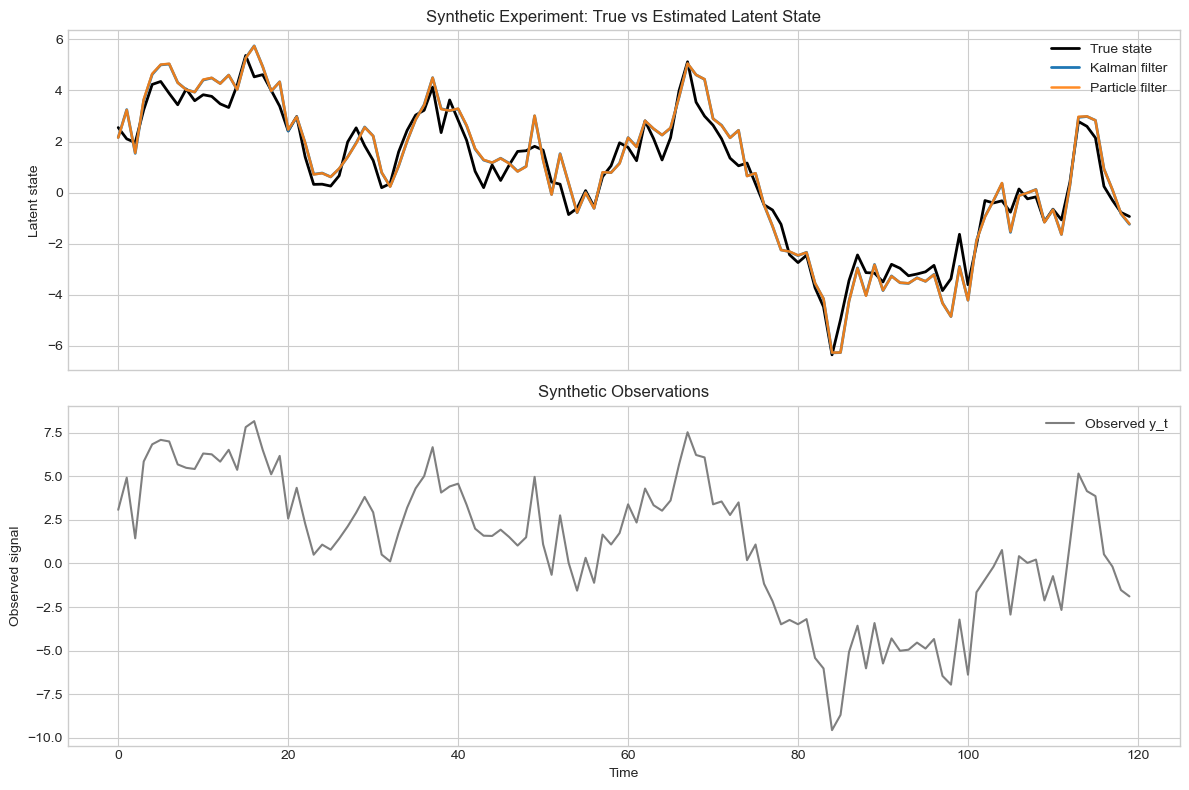

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(x_true, color="black", linewidth=2, label="True state")
axes[0].plot(synth_kf["filtered_mean"], linewidth=2, label="Kalman filter")
axes[0].plot(synth_pf["filtered_mean"], linewidth=1.8, label="Particle filter", alpha=0.9)
axes[0].set_title("Synthetic Experiment: True vs Estimated Latent State")
axes[0].set_ylabel("Latent state")
axes[0].legend()

axes[1].plot(y_synth, color="tab:gray", label="Observed y_t")
axes[1].set_title("Synthetic Observations")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Observed signal")
axes[1].legend()

plt.tight_layout()
plt.show()


## Multi-Country Estimation

Each selected country is estimated **independently** using the same workflow:

1. demean GDP growth,
2. estimate `alpha`, `beta`, and `r` by MLE,
3. recover the latent state using the Kalman filter and particle filter, and
4. compare estimated latent-state paths across countries.


In [6]:
country_results = {}
summary_rows = []
agreement_rows = []
latest_rows = []
state_table = pd.DataFrame()

for idx, country in enumerate(COUNTRIES):
    country_df = prepare_country_series(gdp_df, country)
    y = country_df["growth_centered"].to_numpy()

    mle = fit_mle(y, q=PROJECT_Q)
    kf = mle["kf"]
    pf = particle_filter(
        y,
        alpha=mle["alpha"],
        beta=mle["beta"],
        r=mle["r"],
        q=PROJECT_Q,
        n_particles=4000,
        seed=RNG_SEED + idx + 1,
    )

    country_results[country] = {
        "data": country_df,
        "mle": mle,
        "kf": kf,
        "pf": pf,
    }

    summary_rows.append(
        {
            "country": country,
            "obs": len(country_df),
            "alpha_hat": mle["alpha"],
            "beta_hat": mle["beta"],
            "r_hat": mle["r"],
            "loglik": mle["loglik"],
            "mean_growth": country_df["gdp_growth"].mean(),
            "std_growth": country_df["gdp_growth"].std(),
        }
    )

    agreement_rows.append(
        {
            "country": country,
            "pf_kf_corr": np.corrcoef(kf["filtered_mean"], pf["filtered_mean"])[0, 1],
            "pf_kf_mad": np.mean(np.abs(kf["filtered_mean"] - pf["filtered_mean"])),
            "pf_kf_max_abs_diff": np.max(np.abs(kf["filtered_mean"] - pf["filtered_mean"])),
            "ess_mean": pf["ess"].mean(),
            "ess_min": pf["ess"].min(),
        }
    )

    latest_rows.append(
        {
            "country": country,
            "latest_year": int(country_df["year"].iloc[-1]),
            "latest_growth": country_df["gdp_growth"].iloc[-1],
            "kf_output_gap_latest": kf["filtered_mean"][-1],
            "pf_output_gap_latest": pf["filtered_mean"][-1],
        }
    )

    tmp = country_df[["year"]].copy()
    tmp[country] = kf["filtered_mean"]
    state_table = tmp if state_table.empty else state_table.merge(tmp, on="year", how="outer")

summary_table = pd.DataFrame(summary_rows).sort_values("country").reset_index(drop=True)
agreement_table = pd.DataFrame(agreement_rows).sort_values("country").reset_index(drop=True)
latest_table = pd.DataFrame(latest_rows).sort_values("kf_output_gap_latest", ascending=False).reset_index(drop=True)

print("Estimated model parameters by country")
display(summary_table)
print("Particle filter vs Kalman filter agreement")
display(agreement_table)
print("Latest-year output-gap comparison")
display(latest_table)


Estimated model parameters by country


,country,obs,alpha_hat,beta_hat,r_hat,loglik,mean_growth,std_growth
0,Canada,64,0.9472,0.3860,4.1873,-141.5324,3.0277,2.3508
1,China,64,0.6251,5.7693,0.0500,-203.2737,7.9209,6.6320
2,France,64,0.9731,0.4004,3.5016,-137.4870,2.6757,2.4084
3,Germany,64,0.2776,2.1864,0.0500,-141.2683,2.2178,2.3045
4,India,64,0.0282,3.1900,0.0912,-165.3331,5.2412,3.2306
5,Japan,64,0.9793,0.8130,5.1419,-154.8738,3.3186,3.8803
6,United Kingdom,64,0.0342,2.6137,0.0517,-152.5318,2.2774,2.6454
7,United States,64,0.2208,2.0029,0.0500,-135.7020,3.0157,2.0835


Particle filter vs Kalman filter agreement


,country,pf_kf_corr,pf_kf_mad,pf_kf_max_abs_diff,ess_mean,ess_min
0,Canada,0.9999,0.0295,0.1196,"2,822.9683",868.6286
1,China,0.9841,0.0326,1.9313,181.6799,1.0000
2,France,0.9999,0.0320,0.1067,"2,853.7858",400.5265
3,Germany,0.9999,0.0051,0.1218,421.7865,3.4193
4,India,1.0000,0.0046,0.0737,400.2191,1.7157
5,Japan,1.0000,0.0286,0.1313,"2,589.9652",547.4001
6,United Kingdom,0.9921,0.0211,1.1506,391.2244,1.0015
7,United States,1.0000,0.0040,0.0388,452.7603,24.5901


Latest-year output-gap comparison


,country,latest_year,latest_growth,kf_output_gap_latest,pf_output_gap_latest
0,India,2024,6.4948,0.3898,0.3904
1,United States,2024,2.7930,-0.1100,-0.1144
2,United Kingdom,2024,1.1264,-0.4373,-0.4400
3,China,2024,4.9774,-0.5099,-0.5132
4,Germany,2024,-0.4959,-1.2323,-1.2303
5,Canada,2024,1.5548,-2.0611,-2.0794
6,France,2024,1.1905,-2.8523,-2.8691
7,Japan,2024,0.1043,-3.2332,-3.2299


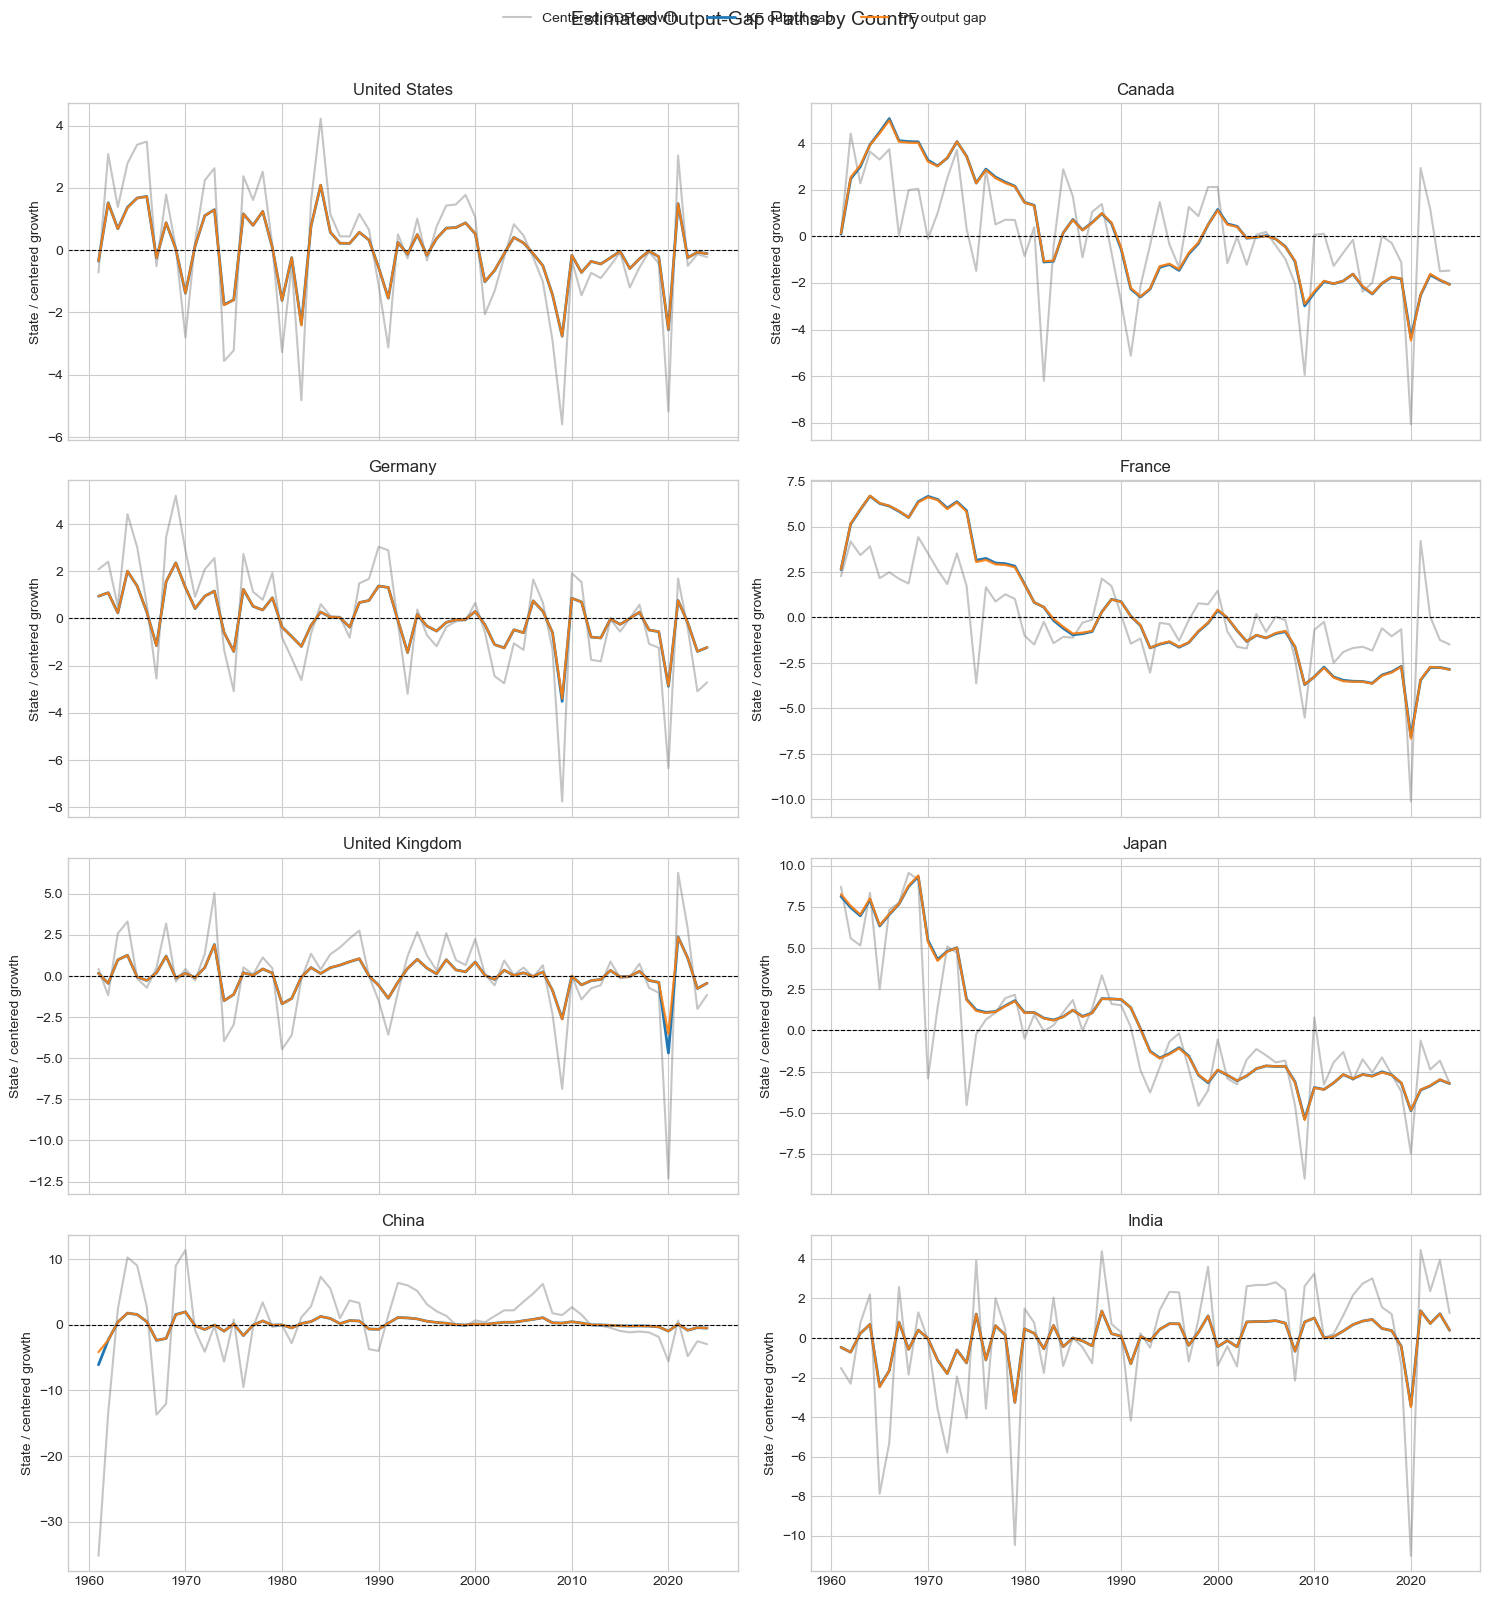

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16), sharex=True)
axes = axes.ravel()

for ax, country in zip(axes, COUNTRIES):
    result = country_results[country]
    data = result["data"]
    kf_state = result["kf"]["filtered_mean"]
    pf_state = result["pf"]["filtered_mean"]

    ax.plot(data["year"], data["growth_centered"], color="tab:gray", alpha=0.45, label="Centered GDP growth")
    ax.plot(data["year"], kf_state, linewidth=2, label="KF output gap")
    ax.plot(data["year"], pf_state, linewidth=1.6, alpha=0.9, label="PF output gap")
    ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8)
    ax.set_title(country)
    ax.set_ylabel("State / centered growth")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.suptitle("Estimated Output-Gap Paths by Country", y=0.995, fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


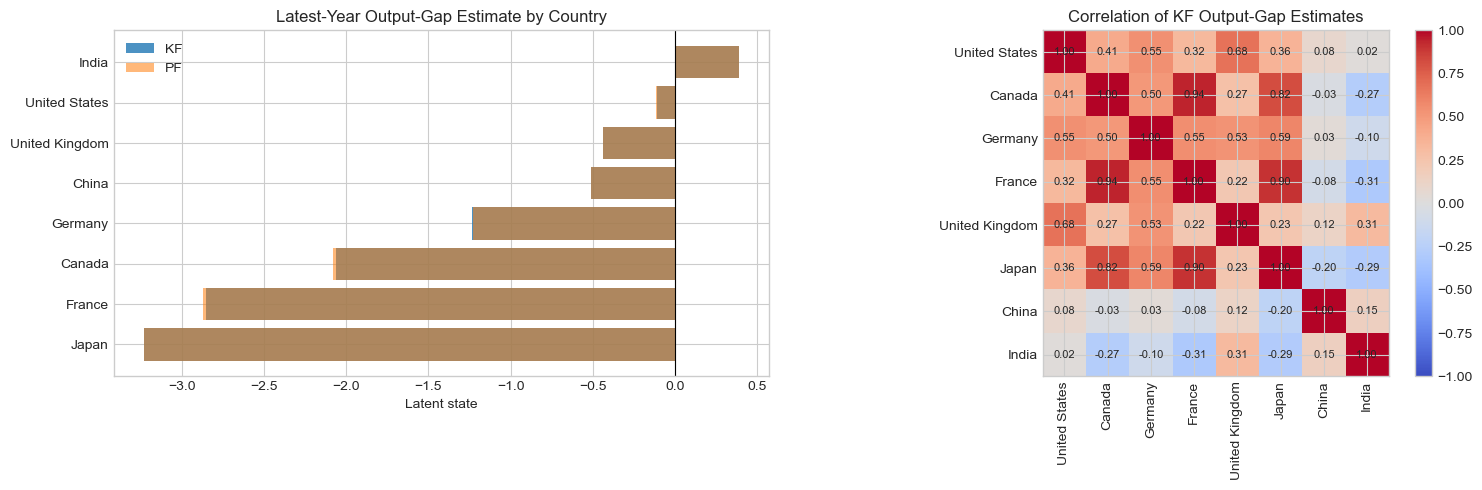

In [8]:
latest_plot = latest_table.sort_values("kf_output_gap_latest", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(latest_plot["country"], latest_plot["kf_output_gap_latest"], color="tab:blue", alpha=0.8, label="KF")
axes[0].barh(latest_plot["country"], latest_plot["pf_output_gap_latest"], color="tab:orange", alpha=0.55, label="PF")
axes[0].axvline(0.0, color="black", linewidth=0.8)
axes[0].set_title("Latest-Year Output-Gap Estimate by Country")
axes[0].set_xlabel("Latent state")
axes[0].legend()

corr = state_table.drop(columns="year").corr()
im = axes[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.index)))
axes[1].set_xticklabels(corr.columns, rotation=90)
axes[1].set_yticklabels(corr.index)
axes[1].set_title("Correlation of KF Output-Gap Estimates")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        axes[1].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


In [9]:
parameter_rankings = summary_table[["country", "alpha_hat", "beta_hat", "r_hat"]].copy()
parameter_rankings["state_persistence_rank"] = parameter_rankings["alpha_hat"].rank(ascending=False, method="dense").astype(int)
parameter_rankings["signal_loading_rank"] = parameter_rankings["beta_hat"].rank(ascending=False, method="dense").astype(int)
parameter_rankings["noise_rank"] = parameter_rankings["r_hat"].rank(ascending=True, method="dense").astype(int)

print("Cross-country parameter ranking summary")
display(parameter_rankings.sort_values("state_persistence_rank"))


Cross-country parameter ranking summary


,country,alpha_hat,beta_hat,r_hat,state_persistence_rank,signal_loading_rank,noise_rank
5,Japan,0.9793,0.8130,5.1419,1,6,8
2,France,0.9731,0.4004,3.5016,2,7,6
0,Canada,0.9472,0.3860,4.1873,3,8,7
1,China,0.6251,5.7693,0.0500,4,1,1
3,Germany,0.2776,2.1864,0.0500,5,4,3
7,United States,0.2208,2.0029,0.0500,6,5,2
6,United Kingdom,0.0342,2.6137,0.0517,7,3,4
4,India,0.0282,3.1900,0.0912,8,2,5


## Discussion and Conclusion

### Is a multi-country version proper under the PDF guidance?

Yes, if it is implemented as a **set of comparable country-specific models** rather than as a pooled model with new cross-country structure.

### What this notebook shows

- The **synthetic experiment** validates the estimation workflow and confirms that the particle filter closely tracks the Kalman filter in this linear-Gaussian setting.
- The **country-by-country estimates** let us compare persistence (`alpha`), signal loading (`beta`), noise (`r`), and the latest estimated cyclical state across countries.
- The **PF/KF agreement table** shows whether the Monte Carlo approximation stays close to the linear-Gaussian benchmark for each country.

### Interpretation

Because the real-data model uses only GDP growth, each latent state should be interpreted as a **country-specific cyclical growth factor / output-gap proxy** rather than as an official structural output gap.

### Limitations

- Countries are estimated independently, so cross-country spillovers are not modeled.
- The latent-state scale is identified through the `q = 1` normalization.
- A richer macroeconomic specification would use more observables per country and potentially a hierarchical or panel-state-space framework.
